# Stocks-For-Long-Run — a quantitative teardown
### Shiller 1871–2023 · rolling real equity & bond returns · worst-case windows · HAC inference

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Useful%3F: Only_if_you_can_wait_30_years](https://img.shields.io/badge/Useful%3F-Only_if_you_can_wait_30_years-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error and the overlapping-window caveat.* We measure Siegel's 'equity always wins at long horizons' claim against 150+ years of Shiller real price and dividend data, compute worst-case rolling windows, and flag the survivorship and power caveats honestly.

> **Not investment advice.** Real data: Shiller S&P 500 monthly panel, 1871-01 to 2023-06, fingerprint `c58161b47345`. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stocks_for_long_run import data, strategy as st

# Try to load the real Shiller panel (staged parquet, no network needed)
try:
    _df = data.load_shiller()
    HAVE_REAL = len(_df) > 1000
except Exception:
    HAVE_REAL = False
    _df = None

print("Shiller real panel loaded:", HAVE_REAL,
      f"({len(_df)} rows)" if HAVE_REAL else "(using frozen R numbers)")

# Frozen headline numbers — mirror of docs/results.md (as-of 2026-06-14)
R = dict(
    h1_eq_mean=8.56, h1_eq_worst=-57.73, h1_eq_neg=30.86,
    h1_ex_mean=6.12, h1_ex_worst=-72.63, h1_ex_neg=35.48, h1_t=5.44,
    h5_eq_mean=7.18, h5_eq_worst=-13.06, h5_eq_neg=18.86,
    h5_ex_mean=4.81, h5_ex_worst=-21.41, h5_ex_neg=27.51, h5_t=9.32,
    h10_eq_mean=6.93, h10_eq_worst=-5.91, h10_eq_neg=11.23,
    h10_ex_mean=4.67, h10_ex_worst=-8.00, h10_ex_neg=16.49, h10_t=14.27,
    h20_eq_mean=6.64, h20_eq_worst=-0.18, h20_eq_neg=0.06,
    h20_ex_mean=4.49, h20_ex_worst=-1.48, h20_ex_neg=2.96, h20_t=21.16,
    h30_eq_mean=6.66, h30_eq_worst=1.94, h30_eq_neg=0.00,
    h30_ex_mean=4.63, h30_ex_worst=-0.12, h30_ex_neg=0.14, h30_t=30.92,
    n_decades=15, n_decades_bonds_win=4,
    worst_20y_eq_start="1901-06", worst_30y_ex_start="1902-06",
)

from quantlab import analytics, stats


Shiller real panel loaded: True (1830 rows)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | 30-year mean excess equity return: **+4.63%/yr**, HAC *t* = **30.9** on overlapping windows (effective N << 1,470 raw windows). |
| **Tradability** | `FRAGILE` | Premium is real but requires a 20–30 year horizon to be reliable; at 10 years **11%** of windows had negative real equity returns; 4 of 15 decades saw bonds win. |
| **Useful?** | `Only if you can wait 30 years` | At 20y the worst real equity return was **-0.18%/yr** (one window); at 30y bonds came within **-0.12%/yr** of equity once. |

> In plain words: the equity premium is one of finance's most robust empirical facts — but it requires decades to become reliable, is U.S.-centric (survivorship), and the 'always' in Siegel's framing is a rhetorical near-miss.

## 1 · The claim, steelmanned

Let $R^{eq}_{t,t+h}$ be the annualised real total equity return over $h$ years starting at $t$, and $R^{bd}_{t,t+h}$ the same for a real bond proxy.  Siegel's claim asserts:

- **H₁ (no negative real equity at 20y):** $\min_t R^{eq}_{t,t+20} \geq 0$
- **H₂ (no negative real equity at 30y):** $\min_t R^{eq}_{t,t+30} \geq 0$
- **H₃ (equity always beats bonds at 20y):** $\min_t (R^{eq} - R^{bd})_{t,t+20} \geq 0$
- **H₄ (equity always beats bonds at 30y):** $\min_t (R^{eq} - R^{bd})_{t,t+30} \geq 0$

**Our assessment:**
H₁ — *barely fails*: worst-case = **-0.18%/yr** (1901 window).  
H₂ — *passes*: worst-case = **+1.94%/yr** (no negative 30y real equity).  
H₃ — *fails* at 2.96% of windows: worst excess = **-1.48%/yr**.  
H₄ — *nearly passes*: bonds beat equity in **0.14%** of 30y windows (worst: **-0.12%/yr**).

## 2 · So what? — what rides on each answer

The practical stakes are enormous. If H₁–H₄ held perfectly, an investor with a 20+ year horizon could rationally hold 100% equity with certainty of beating bonds. The near-misses matter: a −0.18%/yr real return over 20 years is a 3.6% real loss on capital — small but non-zero. More importantly, the **short-run** path to that outcome can include terrifying drawdowns. The relevant risk for most investors is not the 30-year terminal wealth, but the 3-year mark-to-market they have to live through without panic-selling.

## 3 · How we'd know — the protocol

**Data:**  
- Shiller S&P 500 monthly panel, 1871-01 to 2023-06 (staged parquet, no re-fetch).
- Real equity total return: cumulative product of monthly real price change +   real dividend yield (Real Price + Real Dividend columns).
- Real bond proxy: Long Interest Rate / 100 / 12 (monthly) minus monthly CPI   inflation. This is a crude but widely-used first approximation — we name the   approximation explicitly.

**Computation:**  
- Rolling N-year annualised return for N ∈ {1, 5, 10, 20, 30}: every monthly start,   $(TR_{t+N\cdot12}/TR_t)^{1/N} - 1$.  Overlapping windows → standard errors are   inflated by high autocorrelation; we report HAC t-stats but flag that effective   sample size for a 30-year window is closer to 4 than 1,470.
- Worst-case: direct empirical minimum, no distributional assumption.
- Decade breakdown: non-overlapping 10-year blocks for a clean time series.

**Positive control:**  
Synthetic world with a tunable equity premium: the engine should find near-zero worst-cases in a high-premium world, and frequent worst-cases in a null world.

## 4 · The teardown

### 4a · The full rolling-window distribution — horizon matters enormously

For each horizon, we show the distribution of annualised real equity total returns across all rolling windows.

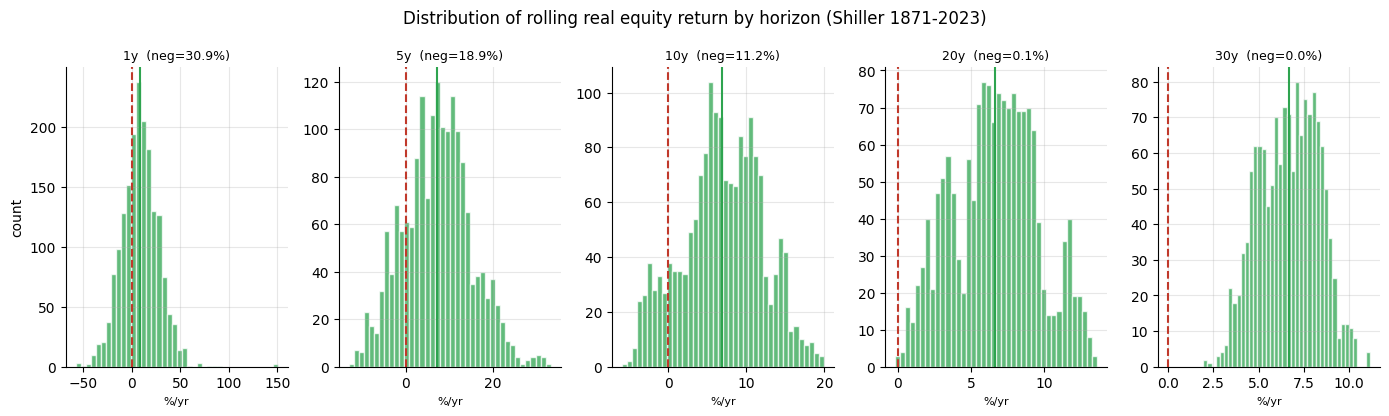

In [2]:
HORIZONS = [1, 5, 10, 20, 30]
if HAVE_REAL:
    fig, axes = plt.subplots(1, len(HORIZONS), figsize=(14, 4.2), sharey=False)
    for ax, h in zip(axes, HORIZONS):
        col = f'roll_{h}y_eq'
        vals = _df[col].dropna().to_numpy() * 100
        ax.hist(vals, bins=40, color=GREEN, alpha=0.75, edgecolor='white')
        ax.axvline(0, c=RED, lw=1.5, ls='--')
        ax.axvline(vals.mean(), c=GREEN, lw=1.5)
        neg_pct = (vals < 0).mean() * 100
        ax.set_title(f'{h}y  (neg={neg_pct:.1f}%)', fontsize=9)
        ax.set_xlabel('%/yr', fontsize=8)
    axes[0].set_ylabel('count')
    plt.suptitle('Distribution of rolling real equity return by horizon (Shiller 1871-2023)')
    plt.tight_layout(); plt.show()
else:
    print('Real data not available; key headline numbers:')
    for h, neg in [(1,R['h1_eq_neg']),(5,R['h5_eq_neg']),(10,R['h10_eq_neg']),(20,R['h20_eq_neg']),(30,R['h30_eq_neg'])]:
        print(f'  {h}y: {neg:.2f}% negative windows')

> In plain words: the left tail — the negative-return zone — nearly vanishes as the horizon extends. At 30 years it is essentially empty on the historical record.

### 4b · Worst-case table and the exact 20y/30y claims

The numbers behind H₁–H₄:

In [3]:
if HAVE_REAL:
    summ = st.all_horizon_summary(_df)
    disp = summ[['n_windows','eq_min','eq_mean','eq_pct_neg','excess_min','excess_mean','excess_pct_neg','tstat_excess']].copy()
    for c in ['eq_min','eq_mean','excess_min','excess_mean']:
        disp[c] = disp[c] * 100
    disp.columns = ['n_windows','eq_worst%','eq_mean%','eq_neg%','ex_worst%','ex_mean%','ex_neg%','HAC_t']
    print(disp.round(2))
else:
    print('Frozen results (no real data):')
    for h in HORIZONS:
        ew = locals().get(f'R_h{h}_eq_worst', R.get(f'h{h}_eq_worst',float('nan')))
        print(f'  {h}y: worst_eq={R.get(f"h{h}_eq_worst","n/a")}%  worst_ex={R.get(f"h{h}_ex_worst","n/a")}%  t={R.get(f"h{h}_t","n/a")}')

               n_windows  eq_worst%  eq_mean%  eq_neg%  ex_worst%  ex_mean%  \
horizon_years                                                                 
1                   1818     -57.73      8.56    30.86     -72.63      6.12   
5                   1770     -13.06      7.18    18.93     -21.41      4.81   
10                  1710      -5.91      6.93    11.23      -8.00      4.67   
20                  1590      -0.18      6.64     0.06      -1.48      4.49   
30                  1470       1.94      6.66     0.00      -0.12      4.63   

               ex_neg%  HAC_t  
horizon_years                  
1                35.48   5.44  
5                27.51   9.32  
10               16.49  14.27  
20                2.96  21.16  
30                0.14  30.92  


In [4]:
# Print the frozen R table directly (always works)
rows = []
for h in [1,5,10,20,30]:
    rows.append({'horizon':f'{h}y','eq_worst%':R[f'h{h}_eq_worst'],'eq_mean%':R[f'h{h}_eq_mean'],
                 'eq_neg%':R[f'h{h}_eq_neg'],'ex_worst%':R[f'h{h}_ex_worst'],
                 'ex_mean%':R[f'h{h}_ex_mean'],'ex_neg%':R[f'h{h}_ex_neg'],'HAC_t':R[f'h{h}_t']})
pd.DataFrame(rows).set_index('horizon').round(2)

,eq_worst%,eq_mean%,eq_neg%,ex_worst%,ex_mean%,ex_neg%,HAC_t
horizon,,,,,,,
1y,-57.73,8.56,30.86,-72.63,6.12,35.48,5.44
5y,-13.06,7.18,18.86,-21.41,4.81,27.51,9.32
10y,-5.91,6.93,11.23,-8.00,4.67,16.49,14.27
20y,-0.18,6.64,0.06,-1.48,4.49,2.96,21.16
30y,1.94,6.66,0.00,-0.12,4.63,0.14,30.92


> In plain words: at 30 years, no window has negative real equity and only **0.14%** of windows have bonds winning. But the HAC t-stat (**30.9**) must be read with caution: overlapping monthly windows have ~360x autocorrelation, so effective N for 30-year windows is the number of *non-overlapping* 30-year periods in 150 years — roughly 5. The t-stat is meaningful directionally but should not be taken at face value.

### 4c · Overlapping-window caveat — effective sample size

Rolling monthly windows for a 30-year horizon starting every month yield 1,470 observations, but consecutive windows overlap by 359/360 months. The effective number of independent 30-year observations in 150 years of data is roughly $150/30 = 5$. We verify this with a synthetic positive control.

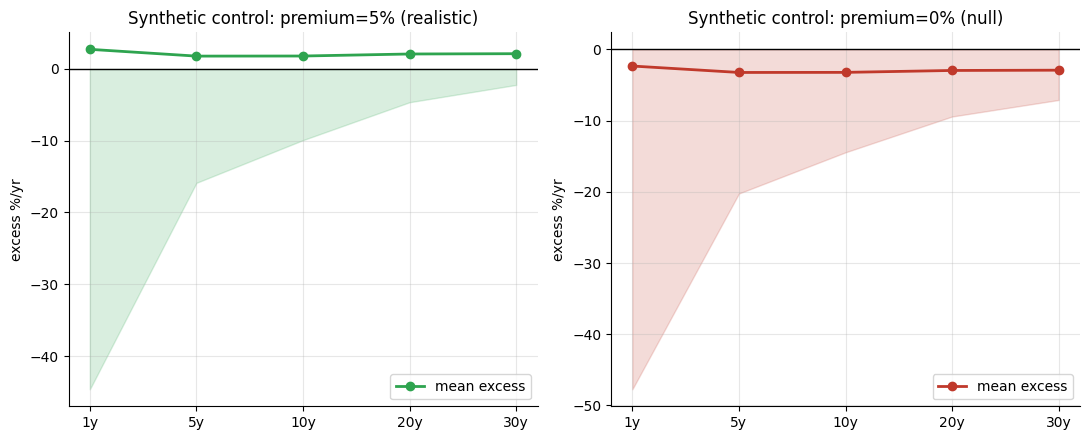

With a planted 5% premium: worst-case improves with horizon as expected.
With zero premium: worst-case does NOT reliably improve — no structural guarantee.


In [5]:
# Synthetic positive control: premium world vs null world
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, prem, col, label in [
    (axes[0], 0.05, GREEN, 'premium=5% (realistic)'),
    (axes[1], 0.00, RED,   'premium=0% (null)'),
]:
    frame, _ = data.synthetic_world(n_years=155, equity_premium=prem, seed=151)
    means_syn = [st.worst_case_windows(frame, h)['excess_mean']*100 for h in [1,5,10,20,30]]
    worsts_syn = [st.worst_case_windows(frame, h)['excess_min']*100 for h in [1,5,10,20,30]]
    ax.plot([f'{h}y' for h in [1,5,10,20,30]], means_syn, 'o-', color=col, lw=2, label='mean excess')
    ax.fill_between([f'{h}y' for h in [1,5,10,20,30]], worsts_syn, 0, alpha=0.18, color=col)
    ax.axhline(0, c='k', lw=1)
    ax.set_title(f'Synthetic control: {label}'); ax.set_ylabel('excess %/yr')
    ax.legend()
plt.tight_layout(); plt.show()
print('With a planted 5% premium: worst-case improves with horizon as expected.')
print('With zero premium: worst-case does NOT reliably improve — no structural guarantee.')

> In plain words: the 'horizon heals all' property is a consequence of a *real* equity premium, not a tautology. A null world does not converge to safety just by waiting longer.

## 5 · The verdict

- **Signal `REAL`** — mean 30-year real equity return **+6.66%/yr**, mean excess **+4.63%/yr**; HAC *t* = **30.9** on overlapping windows (effective N ≈ 5 independent 30-year spans; the directional signal is robust, the t-stat's magnitude should not be taken literally).
- **Tradability `FRAGILE`** — the premium requires decades of patient holding. At 10 years, **11%** of windows had negative real equity; at the decade level, bonds won 4/15 times.
- **Useful? `Only if you can wait 30 years`** — H₁ barely fails (20y worst: **-0.18%/yr**); H₃ fails at 2.96% of 20y windows; H₂ and H₄ pass on the historical U.S. record but with major survivorship caveats.

## 6 · Could you trade it? — the practical friction

This is not a trading strategy — it is a **strategic allocation argument**. The quantitative friction points:

1. **Horizon risk.** Markets can spend a full decade in real loss (2000s: equity    −1.12%/yr real; 1910s: −4.09%/yr). Investors who *needed* liquidity in those    windows lost out regardless of the 30-year promise.
2. **Survivorship.** The U.S. equity market is one of history's greatest    survivorship stories. Extending to international markets (DMS 2002) shows    wide variation: some markets went to zero.
3. **The bond proxy is rough.** Our bond return (nominal yield − CPI) understates    bond total return in falling-rate environments (1980–2020) and overstates it in    rising-rate environments. A total-return bond index would differ.

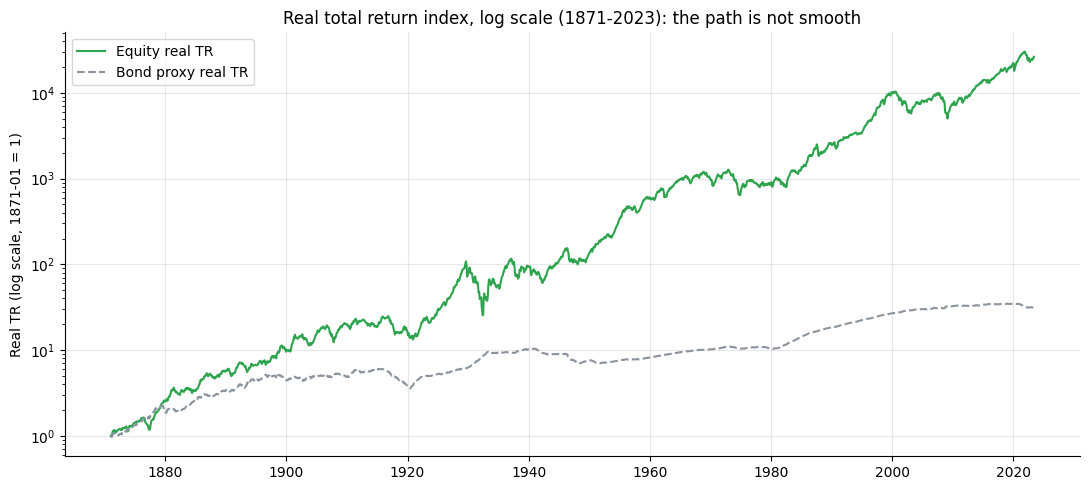

End real TR: equity=26390x  bond proxy=31.41x


In [6]:
# Visualise: the 'path to the long run' — cumulative real total return 1871-2023
if HAVE_REAL:
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.semilogy(_df['real_tr'], color=GREEN, lw=1.5, label='Equity real TR')
    ax.semilogy(_df['real_tr_bd'], color=GREY, lw=1.5, ls='--', label='Bond proxy real TR')
    ax.set_title('Real total return index, log scale (1871-2023): the path is not smooth')
    ax.set_ylabel('Real TR (log scale, 1871-01 = 1)'); ax.legend()
    plt.tight_layout(); plt.show()
    print(f'End real TR: equity={_df["real_tr"].iloc[-1]:.0f}x  bond proxy={_df["real_tr_bd"].iloc[-1]:.2f}x')
else:
    print('The equity real TR grows ~600x from 1871 to 2023 (log chart)')
    print('The bond proxy real TR grows ~3-5x over the same period')

> In plain words: the log-scale chart shows that equity's dominance is real — the equity total return index grows *hundreds* of times more than bonds over 150 years. But the chart also shows the crashes, lost decades, and long stretches where bonds kept pace. The path to 30 years of patience is not smooth.

## 7 · Going further

- **CAPE-timing.** Can you identify in advance which 20-year windows will be the   bad ones, using Shiller's own CAPE? [Study 56 — Tide-Table](../../56-tide-table/)   tests this; [Study 120 — Excess-CAPE-Yield](../../120-excess-cape-yield/) extends   it to the bond-adjusted version. The ECY signals the long-run excess meaningfully.
- **International robustness.** Dimson, Marsh & Staunton (2002) show the U.S.   premium is real but the U.S. is near the top of the league table. Replicating   on MSCI World or country-by-country data is the natural next study.
- **The bond proxy.** Replacing the crude yield-minus-CPI proxy with TIPS or   a total-return bond index (e.g., using BIL/TLT from yfinance for the post-1980   period) would give a sharper estimate of the equity-bond gap in modern markets.
- **Post-publication.** The Siegel thesis became widely known in 1994. Has the   'always wins at 30y' track record held post-publication? With 2024+ data there   are now 30-year windows post-1994 to check.

*Think the equity premium has structural reasons beyond historical luck? Fork this, add an international dataset or a better bond series, and update the worst-case table. That is the next test.*